In [ ]:
import pandas as pd
import numpy as np

In [4]:
pd.set_option('display.max_columns', None) # 컬럼 생략 금지
pd.set_option('display.max_rows', 200) # 행 100개까지 표시
pd.options.display.float_format='{:.0f}'.format # float data 소수점 이하 날리고 표시

In [5]:
df = pd.read_csv("data/real_estate_total_edit.csv", encoding="euc-kr")
df.head()

C:\Users\gorhk\AppData\Local\Temp\ipykernel_10016\569592905.py:1: DtypeWarning: Columns (14) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data/real_estate_total_edit.csv", encoding="euc-kr")


,CGG_CD,CGG_NM,STDG_CD,STDG_NM,BLDG_NM,CTRT_DAY,THING_AMT,ARCH_AREA,LAND_AREA,FLR,RGHT_SE,RTRCN_DAY,ARCH_YR,BLDG_USG,DCLR_SE
0,11500,강서구,10300,화곡동,"우장산아이파크,이편한세상",2019-04-25,95000,102,NaN,10,NaN,NaN,2008,아파트,NaN
1,11410,서대문구,11200,대현동,럭키대현,2019-03-16,70000,83,NaN,10,NaN,NaN,1999,아파트,NaN
2,11590,동작구,10700,사당동,현대,2019-02-21,49500,52,NaN,10,NaN,NaN,1991,아파트,NaN
3,11350,노원구,10500,상계동,초산빌라,2019-01-21,16000,41,18,1,NaN,NaN,1996,연립다세대,NaN
4,11380,은평구,11000,증산동,궁전맨션(189-63),2019-01-03,43000,54,27,2,NaN,NaN,1992,연립다세대,NaN


In [6]:
df['ARCH_YR'].isna().sum() # 3416

# 업데이트할 정밀 단지 정보 리스트 (자치구, 법정동, 본번, 부번, 건물명, 건물용도, 건축년도)
build_info = [
    ('송파구', '문정동', '파크하비오', '오피스텔', 2016),
    ('송파구', '문정동', '엠스테이트', '오피스텔', 2016),
    ('동대문구', '용두동', '동대문 푸르지오시티', '오피스텔', 2016),
    ('용산구', '한강로2가', '래미안 용산 더 센트럴', '오피스텔', 2017),
    ('송파구', '방이동', '대명벨리온', '오피스텔', 2017),
    ('마포구', '신공덕동', '갑을명가시티2', '오피스텔', 2016),
    ('도봉구', '도봉동', '도봉 투웨니퍼스트 2단지', '오피스텔', 2017)
]

# 반복문을 통해 모든 조건을 만족하는 행의 건축년도 업데이트
for gu, dong, bldg, usage, year in build_info:
    condition = (
        (df['CGG_NM'] == gu) & 
        (df['STDG_NM'] == dong) & 
        (df['BLDG_NM'] == bldg) & 
        (df['BLDG_USG'] == usage) &
        (df['ARCH_YR'].isnull())
    )
    df.loc[condition, 'ARCH_YR'] = year
    
print("처리 후 남아있는 건축년도 결측치 수:", df['ARCH_YR'].isnull().sum())

# 업데이트 후 남아있는 건축년도 결측치 수: 1043

# 업데이트 후에도 남아있는 결측치를 9999로 채우기 (핵심!)
df['ARCH_YR'] = df['ARCH_YR'].fillna(9999)

# 결과 확인
print("처리 후 남아있는 건축년도 결측치 수:", df['ARCH_YR'].isnull().sum())
print("건축년도가 9999인 데이터 수:", (df['ARCH_YR'] == 9999).sum())

# 실수형(float)을 정수형(int)으로 변환해서 보기 좋게 만들기
df['ARCH_YR'] = df['ARCH_YR'].astype(int)

'''
처리 후 남아있는 건축년도 결측치 수: 0
건축년도가 9999인 데이터 수: 1043
'''



처리 후 남아있는 건축년도 결측치 수: 1043
처리 후 남아있는 건축년도 결측치 수: 0
건축년도가 9999인 데이터 수: 1043


'\n처리 후 남아있는 건축년도 결측치 수: 0\n건축년도가 9999인 데이터 수: 1043\n'

In [7]:
print(df['BLDG_USG'].unique())
print(df.info())

['아파트' '연립다세대' '오피스텔' '단독다가구']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 833614 entries, 0 to 833613
Data columns (total 15 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   CGG_CD     833614 non-null  int64  
 1   CGG_NM     833613 non-null  object 
 2   STDG_CD    833614 non-null  int64  
 3   STDG_NM    833614 non-null  object 
 4   BLDG_NM    776065 non-null  object 
 5   CTRT_DAY   833614 non-null  object 
 6   THING_AMT  833614 non-null  int64  
 7   ARCH_AREA  833614 non-null  float64
 8   LAND_AREA  668824 non-null  float64
 9   FLR        776119 non-null  float64
 10  RGHT_SE    7614 non-null    object 
 11  RTRCN_DAY  25541 non-null   float64
 12  ARCH_YR    833614 non-null  int64  
 13  BLDG_USG   833614 non-null  object 
 14  DCLR_SE    225344 non-null  object 
dtypes: float64(4), int64(4), object(7)
memory usage: 95.4+ MB
None


In [8]:
# 계약일 기준으로 테이블 재정리

df2 = df.copy()
# CTRT_DAY 데이터 타입 object -> datetime 변환
df2['CTRT_DAY'] = pd.to_datetime(df2['CTRT_DAY'], errors='coerce')
display(df2['CTRT_DAY'])
df2['CTRT_DAY'].dt.year.value_counts().sort_index()
# 새로운 계약일 년도 컬럼 생성

df2['CTRT_YEAR'] = df2['CTRT_DAY'].dt.year
# 2018년부터 2024년까지 리스트 설정


target_years = list(range(2018, 2025))

# 해당 연도에 포함되는 데이터만 남기고 copy
df2 = df2[df2['CTRT_DAY'].dt.year.isin(target_years)].copy()

# 전체 행 수 확인
print(f"\n최종 남은 데이터 건수: {len(df2):,}건")

0        2019-04-25
1        2019-03-16
2        2019-02-21
3        2019-01-21
4        2019-01-03
            ...    
833609   2022-07-08
833610   2022-07-08
833611   2022-07-08
833612   2021-07-19
833613   2021-02-08
Name: CTRT_DAY, Length: 833614, dtype: datetime64[ns]


최종 남은 데이터 건수: 820,169건


In [9]:
df2.loc[df2["CGG_NM"].isna()]

,CGG_CD,CGG_NM,STDG_CD,STDG_NM,BLDG_NM,CTRT_DAY,THING_AMT,ARCH_AREA,LAND_AREA,FLR,RGHT_SE,RTRCN_DAY,ARCH_YR,BLDG_USG,DCLR_SE,CTRT_YEAR
829987,26230,NaN,10100,미아동,2020년 2차 행복주택 입주자 모집,2024-01-12,42450,72,0,5,분양권,NaN,0,아파트,중개거래,2024


In [10]:
# 해당 오류 행 제거
df2 = df2.dropna(subset=['CGG_NM'])
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 820168 entries, 0 to 833613
Data columns (total 16 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   CGG_CD     820168 non-null  int64         
 1   CGG_NM     820168 non-null  object        
 2   STDG_CD    820168 non-null  int64         
 3   STDG_NM    820168 non-null  object        
 4   BLDG_NM    763797 non-null  object        
 5   CTRT_DAY   820168 non-null  datetime64[ns]
 6   THING_AMT  820168 non-null  int64         
 7   ARCH_AREA  820168 non-null  float64       
 8   LAND_AREA  656054 non-null  float64       
 9   FLR        763851 non-null  float64       
 10  RGHT_SE    7309 non-null    object        
 11  RTRCN_DAY  25541 non-null   float64       
 12  ARCH_YR    820168 non-null  int64         
 13  BLDG_USG   820168 non-null  object        
 14  DCLR_SE    225343 non-null  object        
 15  CTRT_YEAR  820168 non-null  int32         
dtypes: datetime64[ns](1), flo

In [11]:
df2.loc[df2["FLR"]==-3]

,CGG_CD,CGG_NM,STDG_CD,STDG_NM,BLDG_NM,CTRT_DAY,THING_AMT,ARCH_AREA,LAND_AREA,FLR,RGHT_SE,RTRCN_DAY,ARCH_YR,BLDG_USG,DCLR_SE,CTRT_YEAR
56832,11380,은평구,11400,진관동,우물골2단지두산위브(223~244동)BL2-7,2018-07-26,72500,101,0,-3,NaN,NaN,2010,아파트,NaN,2018
359024,11380,은평구,11400,진관동,우물골2단지두산위브(223~244동)BL2-7,2020-07-23,104000,135,0,-3,NaN,NaN,2010,아파트,NaN,2020
430119,11380,은평구,11400,진관동,은평뉴타운 우물골(두산위브7단지),2020-03-20,82000,135,NaN,-3,NaN,NaN,2010,아파트,NaN,2020
713893,11380,은평구,11400,진관동,우물골2단지두산위브(223~244동)BL2-7,2023-07-29,110000,101,0,-3,NaN,NaN,2010,아파트,중개거래,2023
750174,11170,용산구,13100,한남동,코번하우스,2023-02-09,580000,274,211,-3,NaN,NaN,2006,연립다세대,중개거래,2023


In [12]:
# 계약일 - 건축년도 = 계약일 시 건물연식
# 계약일(CTRT_DAY)이 이미 datetime 형식이므로 .dt 접근자를 사용하여 연도를 추출해야 합니다.

# 1. 계약일에서 연도 추출
df2['CTRT_YR'] = df2['CTRT_DAY'].dt.year

# 2. 건축년도 데이터 정제
# 건축년도가 0인 경우(정보 없음) 그대로 빼면 건물이 매우 오래된 것으로 나오므로 유의해야 합니다.
# 우선 계산을 진행합니다.

# 3. 건물 연식(Age) 계산
# 계약년도 - 건축년도
df2['CTRT_BLDG_AGE'] = df2['CTRT_YR'] - df2['ARCH_YR']

# 4. 결과 확인
# 연산 결과 중 음수가 나오거나(건축 전 계약?), 너무 큰 값(건축년도 0)이 있는지 확인합니다.
print(df2[['CTRT_DAY', 'ARCH_YR', 'CTRT_BLDG_AGE']].head(10))
print("\n=== 연식 기초통계량 ===")
print(df2['CTRT_BLDG_AGE'].describe())

# (팁) 건축년도가 0보다 크고 유효한 값들만 추려서 통계를 확인하려면:
valid_age_df = df2[ (df2['ARCH_YR'] > 0) & (df2['ARCH_YR'].notnull()) ]
display(valid_age_df['CTRT_BLDG_AGE'].describe())


    CTRT_DAY  ARCH_YR  CTRT_BLDG_AGE
0 2019-04-25     2008             11
1 2019-03-16     1999             20
2 2019-02-21     1991             28
3 2019-01-21     1996             23
4 2019-01-03     1992             27
5 2018-12-31     2018              0
6 2018-12-31     2007             11
7 2018-12-31     2004             14
8 2018-12-31     1990             28
9 2018-12-31     2018              0

=== 연식 기초통계량 ===
count   820168
mean        26
std        340
min      -7981
25%          7
50%         17
75%         27
max       2024
Name: CTRT_BLDG_AGE, dtype: float64


count   812854
mean         8
std        284
min      -7981
25%          7
50%         17
75%         26
max       1053
Name: CTRT_BLDG_AGE, dtype: float64

In [ ]:
# 1. 0년 이상 150년 이하 필터링
df_valid_age = df2[(df2['CTRT_BLDG_AGE'] >= 0)]

# 2. 용도 리스트
building_types = df_valid_age['BLDG_USG'].unique()

for b_type in building_types:
    print(f"\n{'='*20} [{b_type}] 분석 결과 {'='*20}")
    
    # 해당 용도 데이터 추출
    subset = df_valid_age[df_valid_age['BLDG_USG'] == b_type]
    
    # 용도 내 연식별 통계 (평균, 중앙값, 개수)
    stats = subset.groupby('CTRT_BLDG_AGE')['THING_AMT'].agg(['mean', 'median', 'count'])
    
    # 연식순 정렬
    stats = stats.sort_index()

    # --- 상위 50개 (신축 위주) ---
    print(f"\n>> [{b_type}] 연식 상위 50개 (신축~)")
    display(stats.head(50))
    
    # --- 하위 50개 (구축 위주) ---
    # *데이터가 50개 미만일 경우 중복될 수 있으니 체크
    if len(stats) > 50:
        print(f"\n>> [{b_type}] 연식 하위 50개 (~오래된 순)")
        display(stats.tail(50))
    else:
        print("\n(데이터가 50개 이하여서 하위 표는 생략합니다)")


==================== [아파트] 분석 결과 ====================

>> [아파트] 연식 상위 50개 (신축~)


,mean,median,count
CTRT_BLDG_AGE,,,
0,53201,34550,4998
1,91594,69000,5533
2,111300,102500,6439
3,113201,102500,7961
4,112959,105000,8985
5,107246,104000,8325
6,101240,95000,7552
7,95237,87500,7821
8,95943,79000,8460



>> [아파트] 연식 하위 50개 (~오래된 순)


,mean,median,count
CTRT_BLDG_AGE,,,
20,74877,65000,16384
21,75488,66000,15241
22,72718,64500,13156
23,73680,66800,12065
24,72368,65000,11544
25,71841,63500,10627
26,69812,60000,9976
27,71568,63000,8867
28,68642,60000,7331



==================== [연립다세대] 분석 결과 ====================

>> [연립다세대] 연식 상위 50개 (신축~)


...

,mean,median,count
CTRT_BLDG_AGE,,,
0,28746,26754,10838
1,29868,26200,5871
2,26657,23000,2605
3,26138,22000,2570
4,25044,20000,4126
5,23144,19900,5151
6,22150,19650,5654
7,20916,18000,4478
8,20379,18000,3433



(데이터가 50개 이하여서 하위 표는 생략합니다)

==================== [단독다가구] 분석 결과 ====================

>> [단독다가구] 연식 상위 50개 (신축~)


,mean,median,count
CTRT_BLDG_AGE,,,
0,173308,168000,247
1,169547,157375,304
2,215459,165500,170
3,210633,172189,139
4,188268,148500,174
5,200938,132000,144
6,186569,127250,158
7,189207,143500,145
8,175785,127750,122



>> [단독다가구] 연식 하위 50개 (~오래된 순)


,mean,median,count
CTRT_BLDG_AGE,,,
66,139067,91850,50
67,110139,88000,33
68,88937,80750,24
69,61828,39500,73
70,81444,45000,53
71,85453,60000,44
72,87035,72500,24
73,102258,72500,18
74,121991,64000,19


C:\Users\gorhk\AppData\Local\Temp\ipykernel_10016\1428538810.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=head_50_price.index, y=head_50_price.values, ax=axes[0], palette='Blues_d')
C:\Users\gorhk\AppData\Local\Temp\ipykernel_10016\1428538810.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tail_50_volume.index, y=tail_50_volume.values, ax=axes[1], palette='Greens_d') # 색상 변경 (구분 위해)


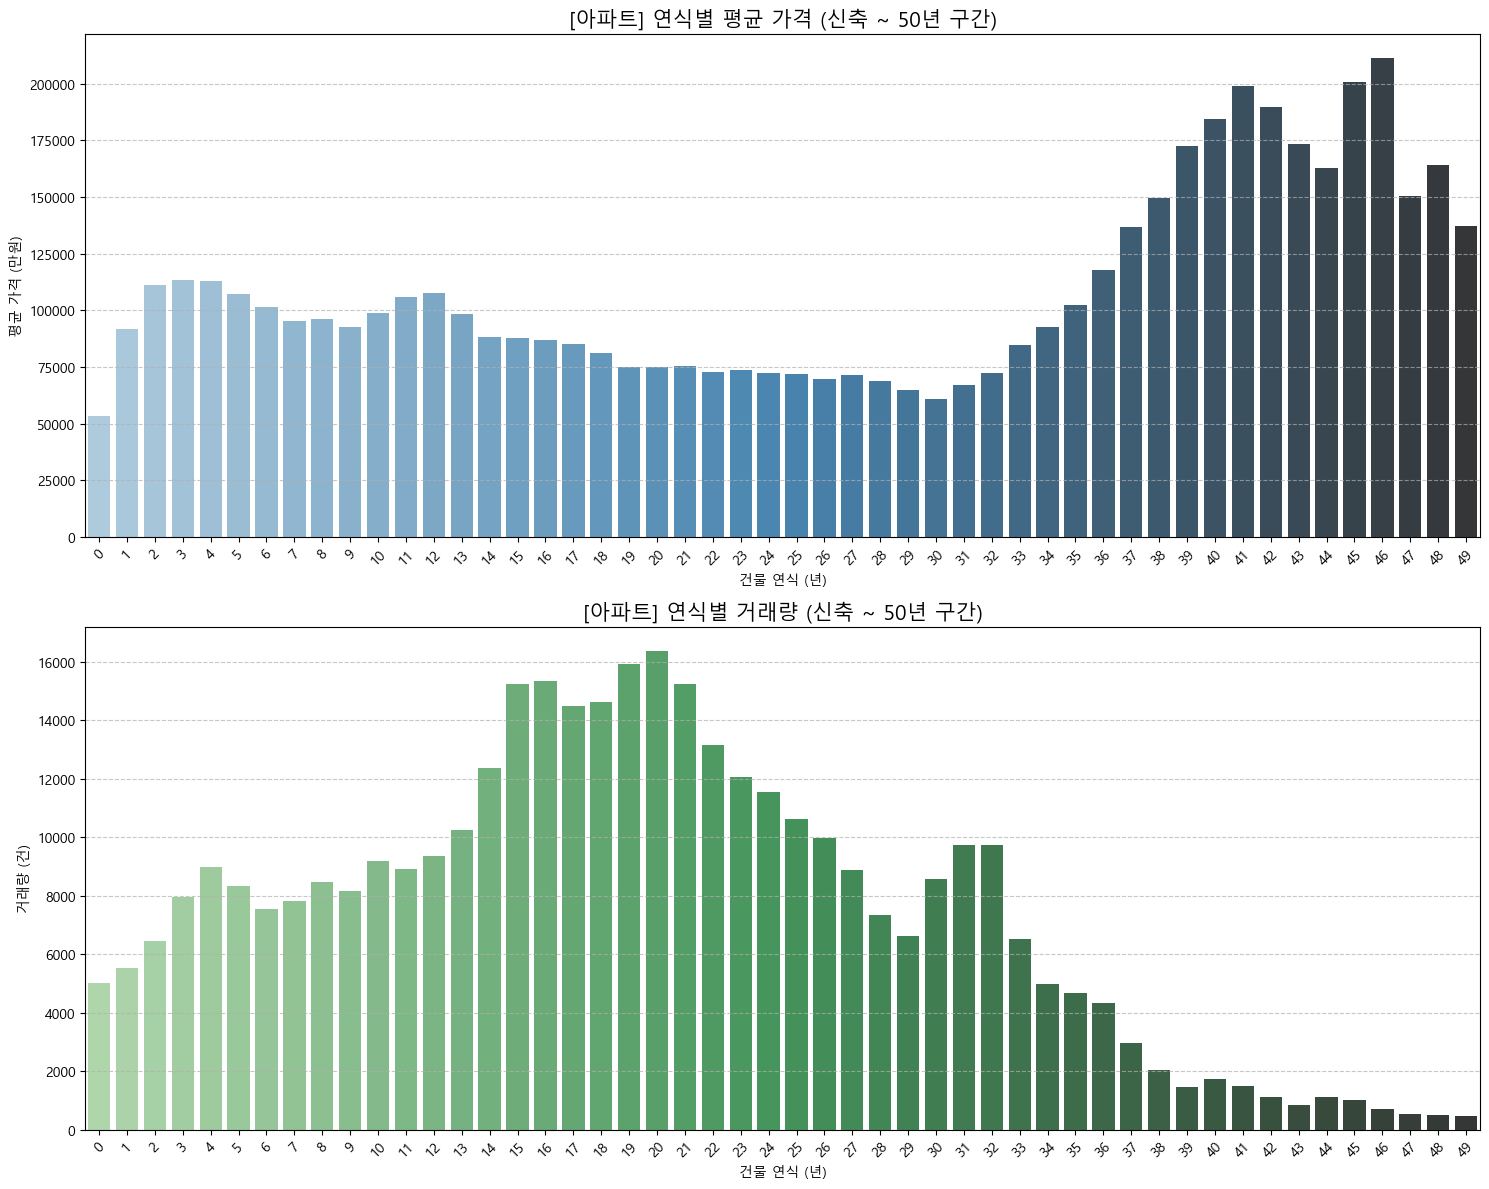

C:\Users\gorhk\AppData\Local\Temp\ipykernel_10016\1428538810.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=head_50_price.index, y=head_50_price.values, ax=axes[0], palette='Blues_d')
C:\Users\gorhk\AppData\Local\Temp\ipykernel_10016\1428538810.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tail_50_volume.index, y=tail_50_volume.values, ax=axes[1], palette='Greens_d') # 색상 변경 (구분 위해)


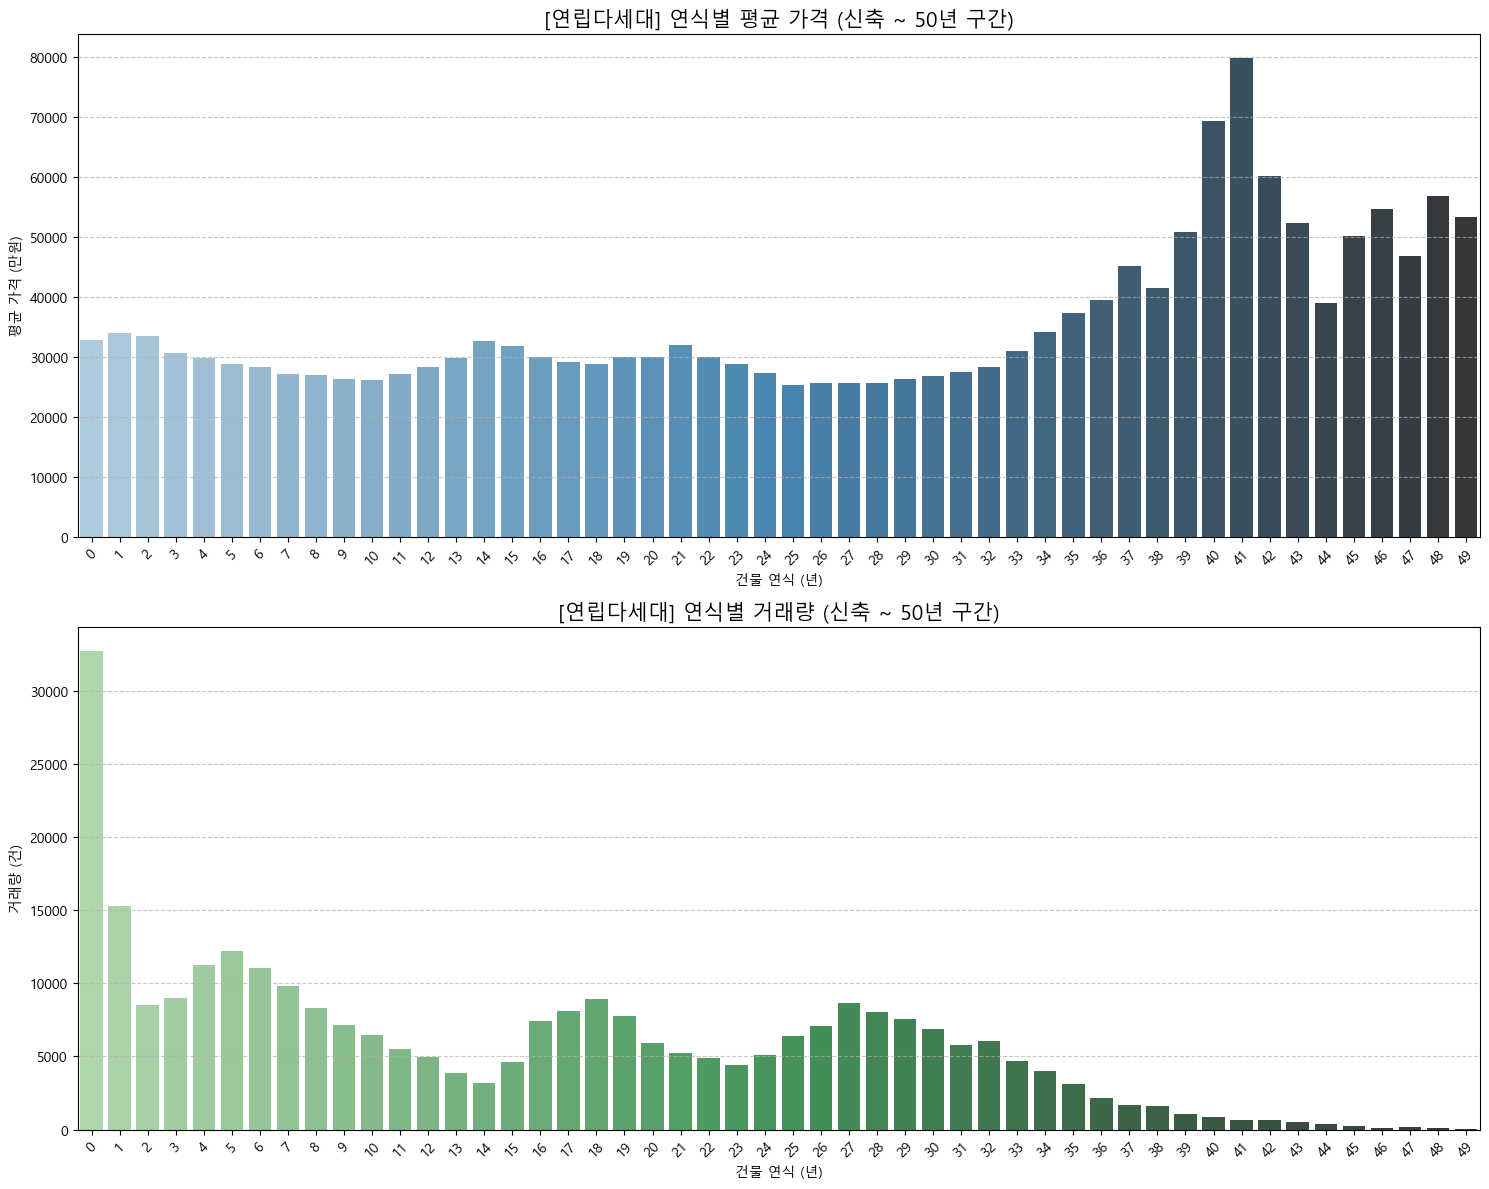

C:\Users\gorhk\AppData\Local\Temp\ipykernel_10016\1428538810.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=head_50_price.index, y=head_50_price.values, ax=axes[0], palette='Blues_d')
C:\Users\gorhk\AppData\Local\Temp\ipykernel_10016\1428538810.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tail_50_volume.index, y=tail_50_volume.values, ax=axes[1], palette='Greens_d') # 색상 변경 (구분 위해)


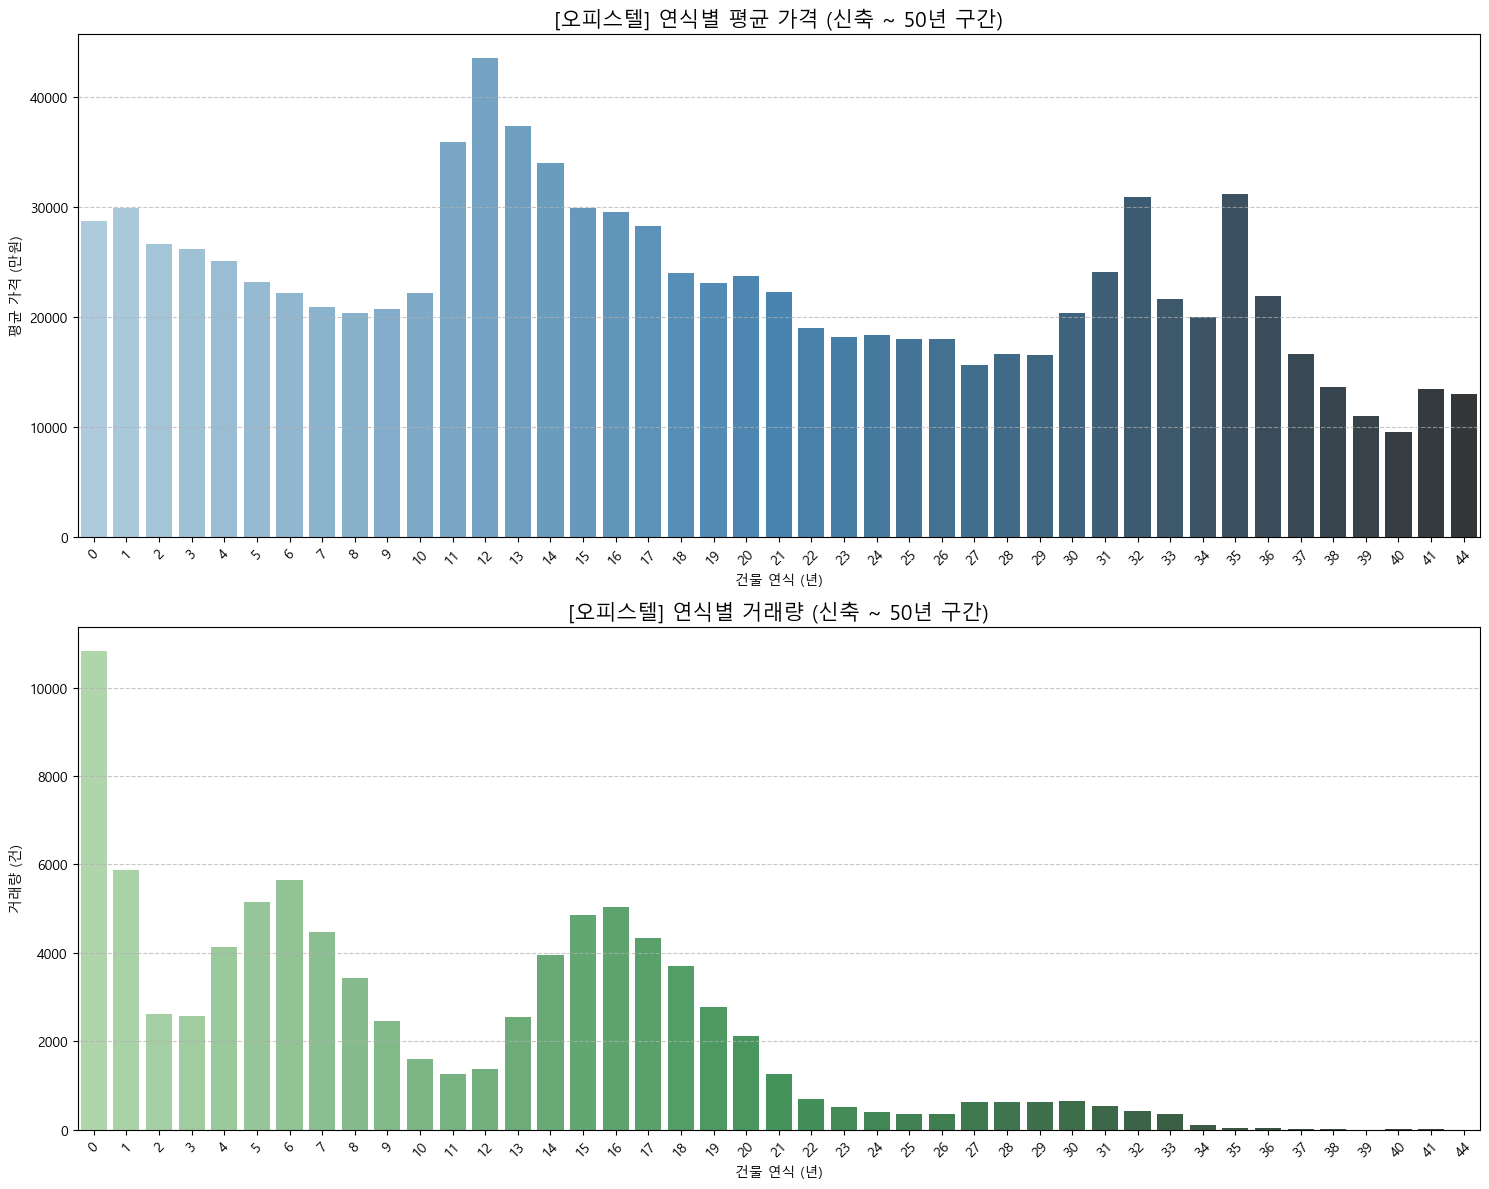

C:\Users\gorhk\AppData\Local\Temp\ipykernel_10016\1428538810.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=head_50_price.index, y=head_50_price.values, ax=axes[0], palette='Blues_d')
C:\Users\gorhk\AppData\Local\Temp\ipykernel_10016\1428538810.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tail_50_volume.index, y=tail_50_volume.values, ax=axes[1], palette='Greens_d') # 색상 변경 (구분 위해)


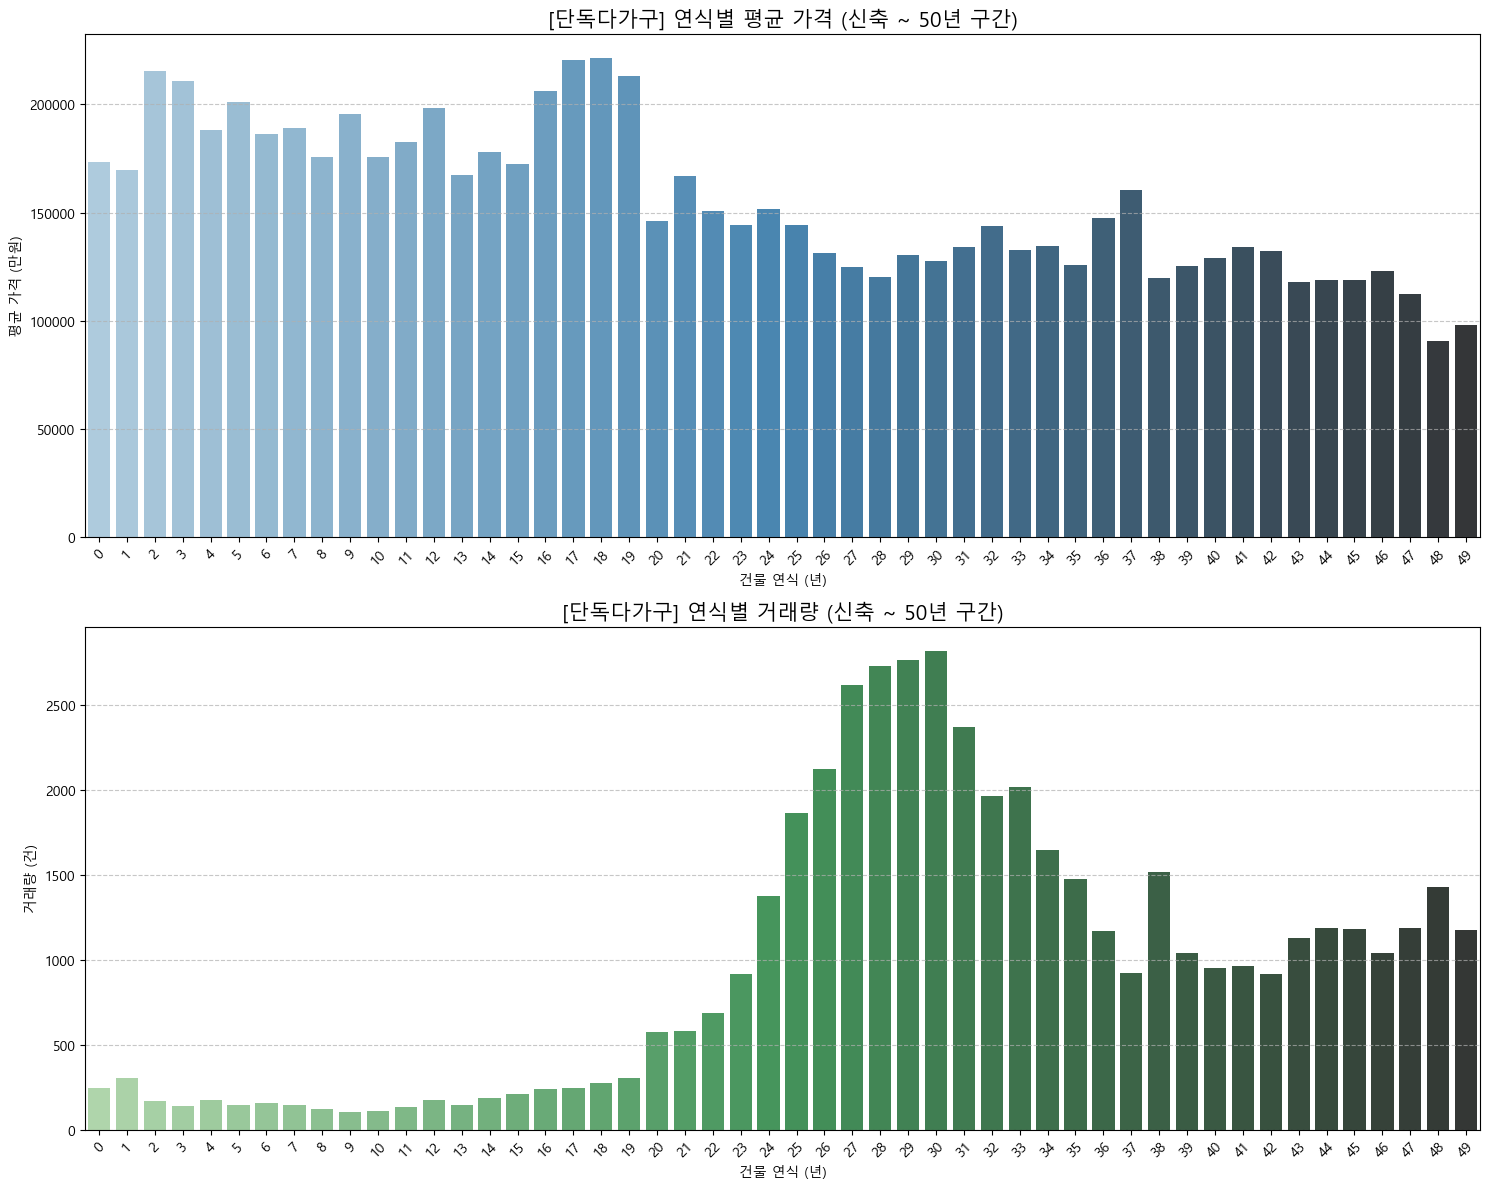

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import platform

# --- 한글 폰트 설정 ---
system_name = platform.system()
if system_name == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif system_name == 'Darwin':
    plt.rc('font', family='AppleGothic')
else:
    plt.rc('font', family='NanumGothic')

plt.rc('axes', unicode_minus=False)
# ---------------------

# 1. 0년 이상 150 이하 데이터만 필터링
df_valid_age = df2[(df2['CTRT_BLDG_AGE'] >= 0) & (df2['CTRT_BLDG_AGE'] < 150)]

# 2. 건물 용도 리스트 추출
building_types = df_valid_age['BLDG_USG'].unique()

for b_type in building_types:
    # 해당 용도의 데이터만 추출
    subset = df_valid_age[df_valid_age['BLDG_USG'] == b_type]
    
    # 1) 가격 통계 (평균)
    age_price = subset.groupby('CTRT_BLDG_AGE')['THING_AMT'].mean().sort_index()
    # 2) 거래량 통계 (건수) - "평균 거래량"은 통상 기간 평균을 의미하나, 여기선 해당 연식의 총 거래량으로 해석
    age_volume = subset.groupby('CTRT_BLDG_AGE')['THING_AMT'].count().sort_index()
    

    # --- 상위 50개 (신축 ~ 50년차): 가격 기준 ---
    head_50_price = age_price.head(50)
    
    # --- 하위 50개 (신축 ~ 50년차): 거래량 기준 ---
    tail_50_volume = age_volume.head(50)
    
    # 그래프 그리기
    fig, axes = plt.subplots(2, 1, figsize=(15, 12))
    
    # 1) 상위 50개 그래프 (평균 가격)
    sns.barplot(x=head_50_price.index, y=head_50_price.values, ax=axes[0], palette='Blues_d')
    axes[0].set_title(f'[{b_type}] 연식별 평균 가격 (신축 ~ 50년 구간)', fontsize=15)
    axes[0].set_xlabel('건물 연식 (년)')
    axes[0].set_ylabel('평균 가격 (만원)')
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].grid(axis='y', linestyle='--', alpha=0.7)

    # 2) 하위 50개 그래프 (거래량) - 변경됨
    sns.barplot(x=tail_50_volume.index, y=tail_50_volume.values, ax=axes[1], palette='Greens_d') # 색상 변경 (구분 위해)
    axes[1].set_title(f'[{b_type}] 연식별 거래량 (신축 ~ 50년 구간)', fontsize=15)
    axes[1].set_xlabel('건물 연식 (년)')
    axes[1].set_ylabel('거래량 (건)') # 라벨 변경
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

C:\Users\gorhk\AppData\Local\Temp\ipykernel_10016\271226823.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=head_50.index, y=head_50.values, ax=axes[0], palette='viridis')
C:\Users\gorhk\AppData\Local\Temp\ipykernel_10016\271226823.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tail_50.index, y=tail_50.values, ax=axes[1], palette='magma')


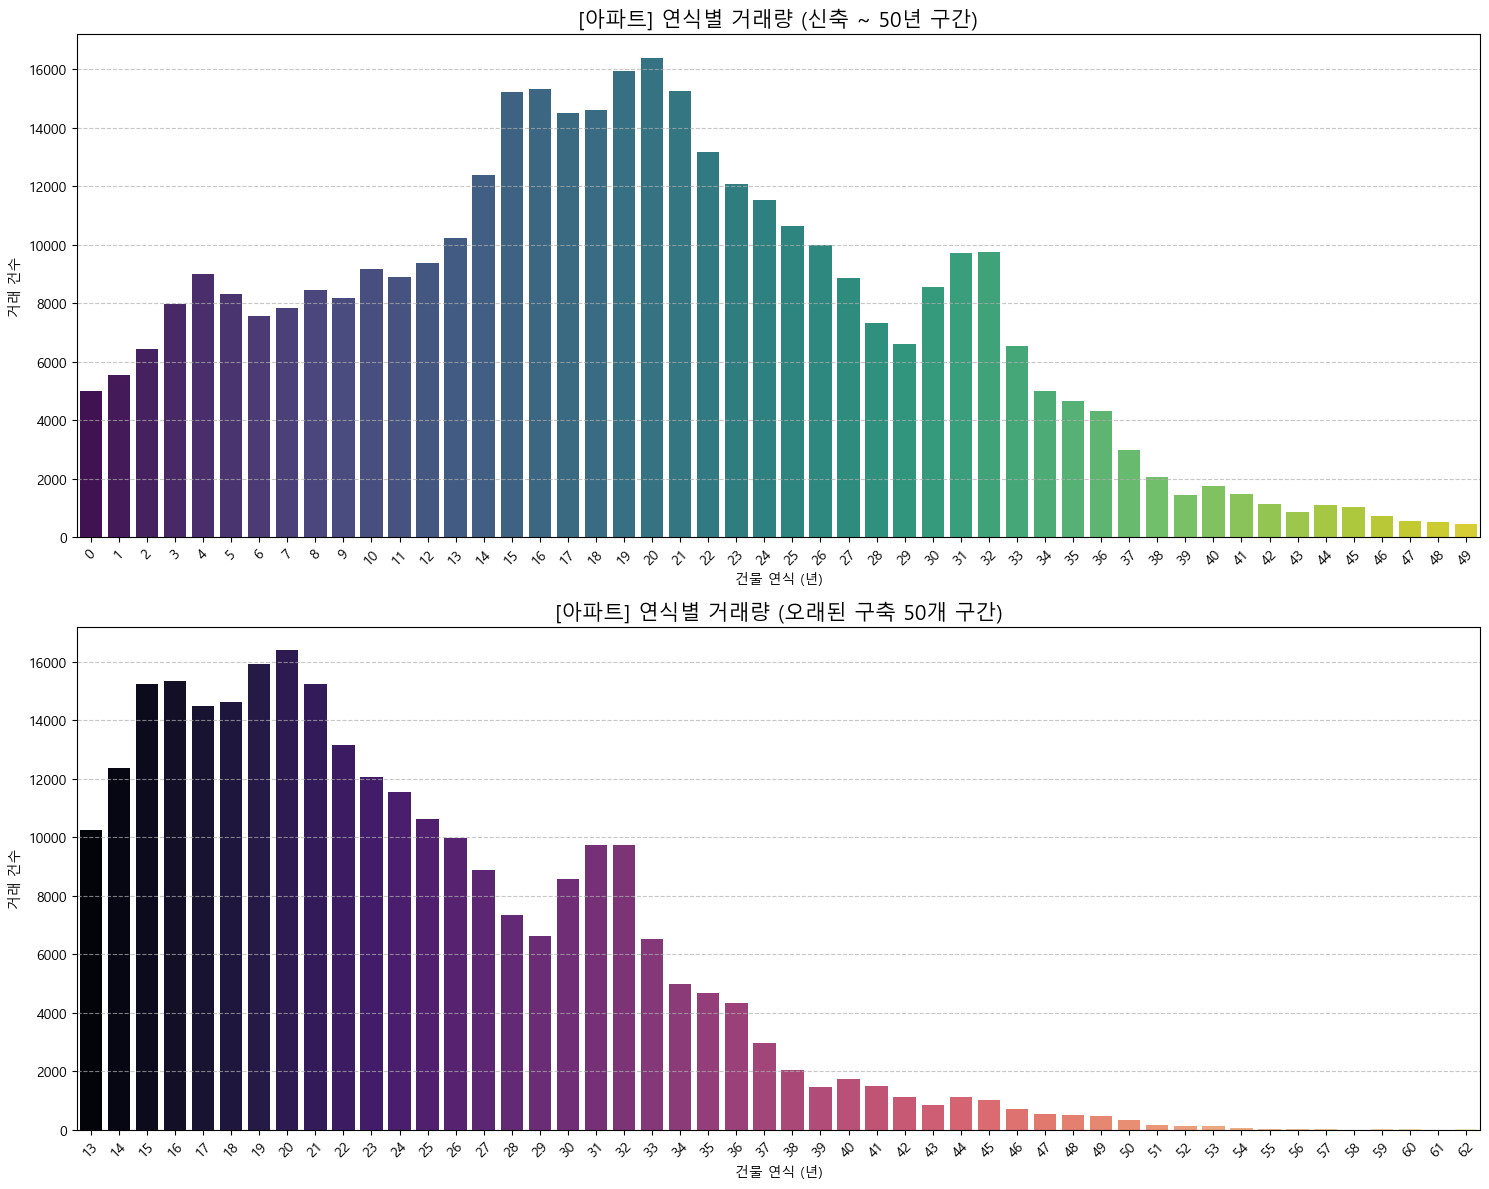

C:\Users\gorhk\AppData\Local\Temp\ipykernel_10016\271226823.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=head_50.index, y=head_50.values, ax=axes[0], palette='viridis')
C:\Users\gorhk\AppData\Local\Temp\ipykernel_10016\271226823.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tail_50.index, y=tail_50.values, ax=axes[1], palette='magma')


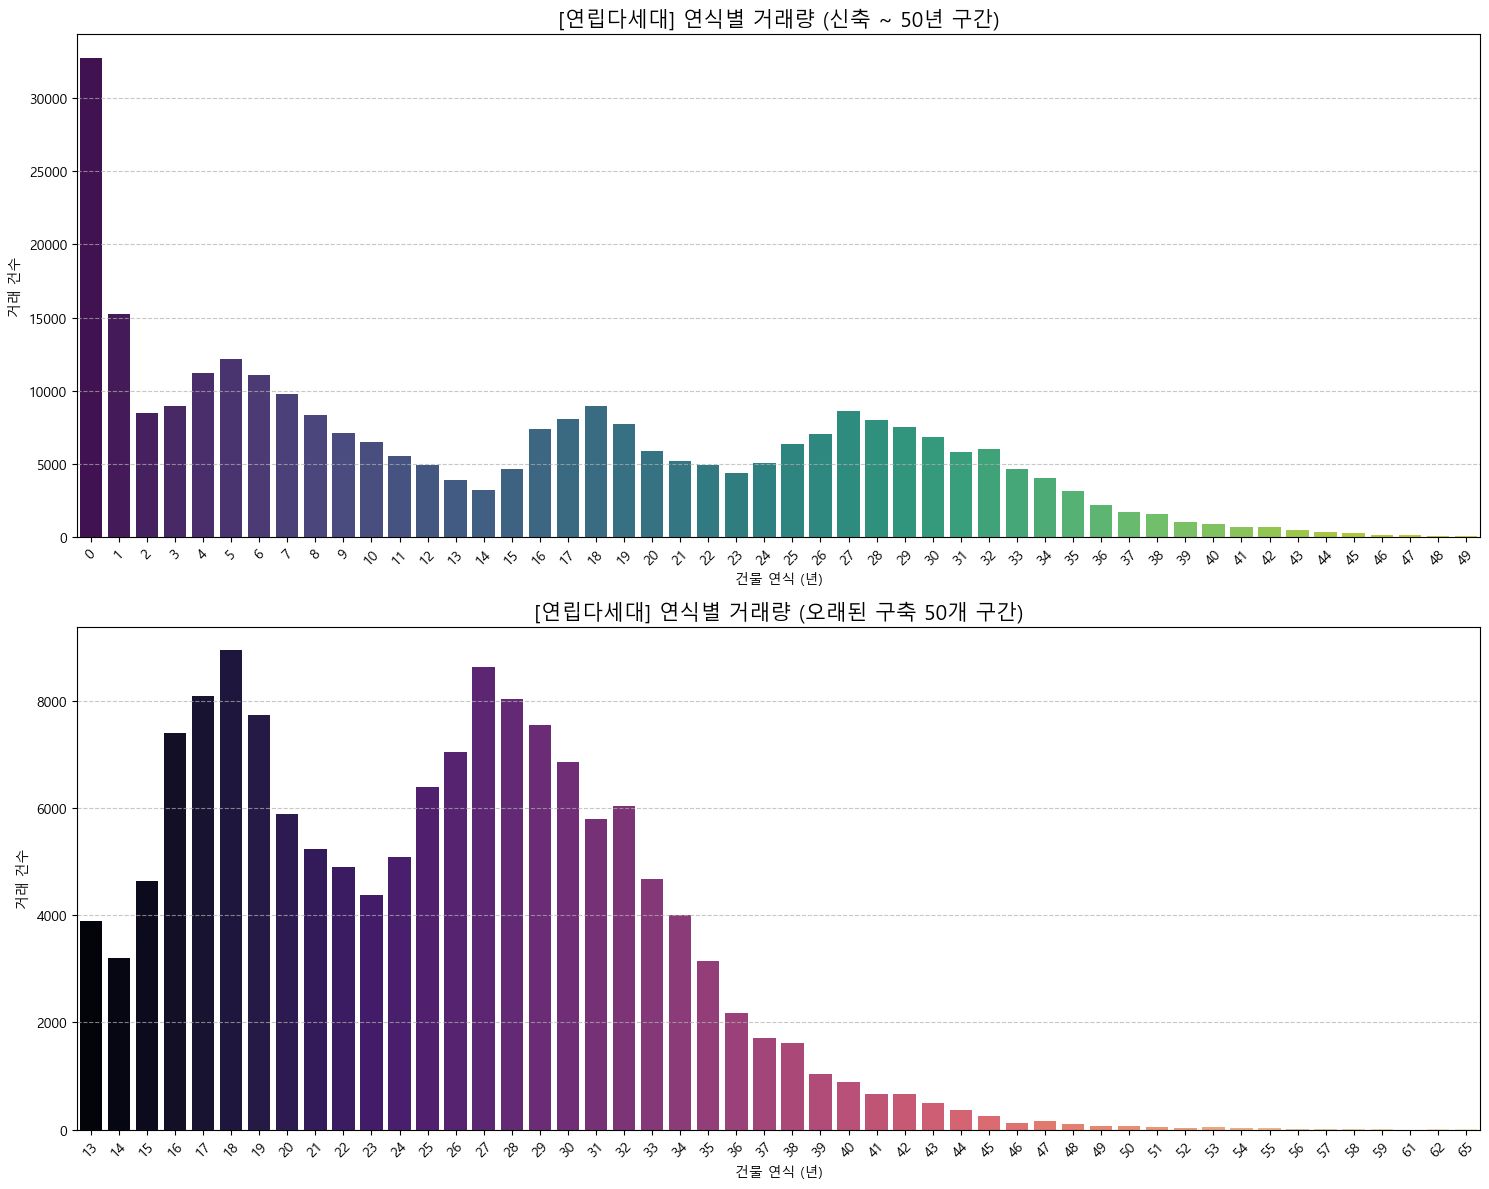

C:\Users\gorhk\AppData\Local\Temp\ipykernel_10016\271226823.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=head_50.index, y=head_50.values, ax=axes[0], palette='viridis')
C:\Users\gorhk\AppData\Local\Temp\ipykernel_10016\271226823.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tail_50.index, y=tail_50.values, ax=axes[1], palette='magma')


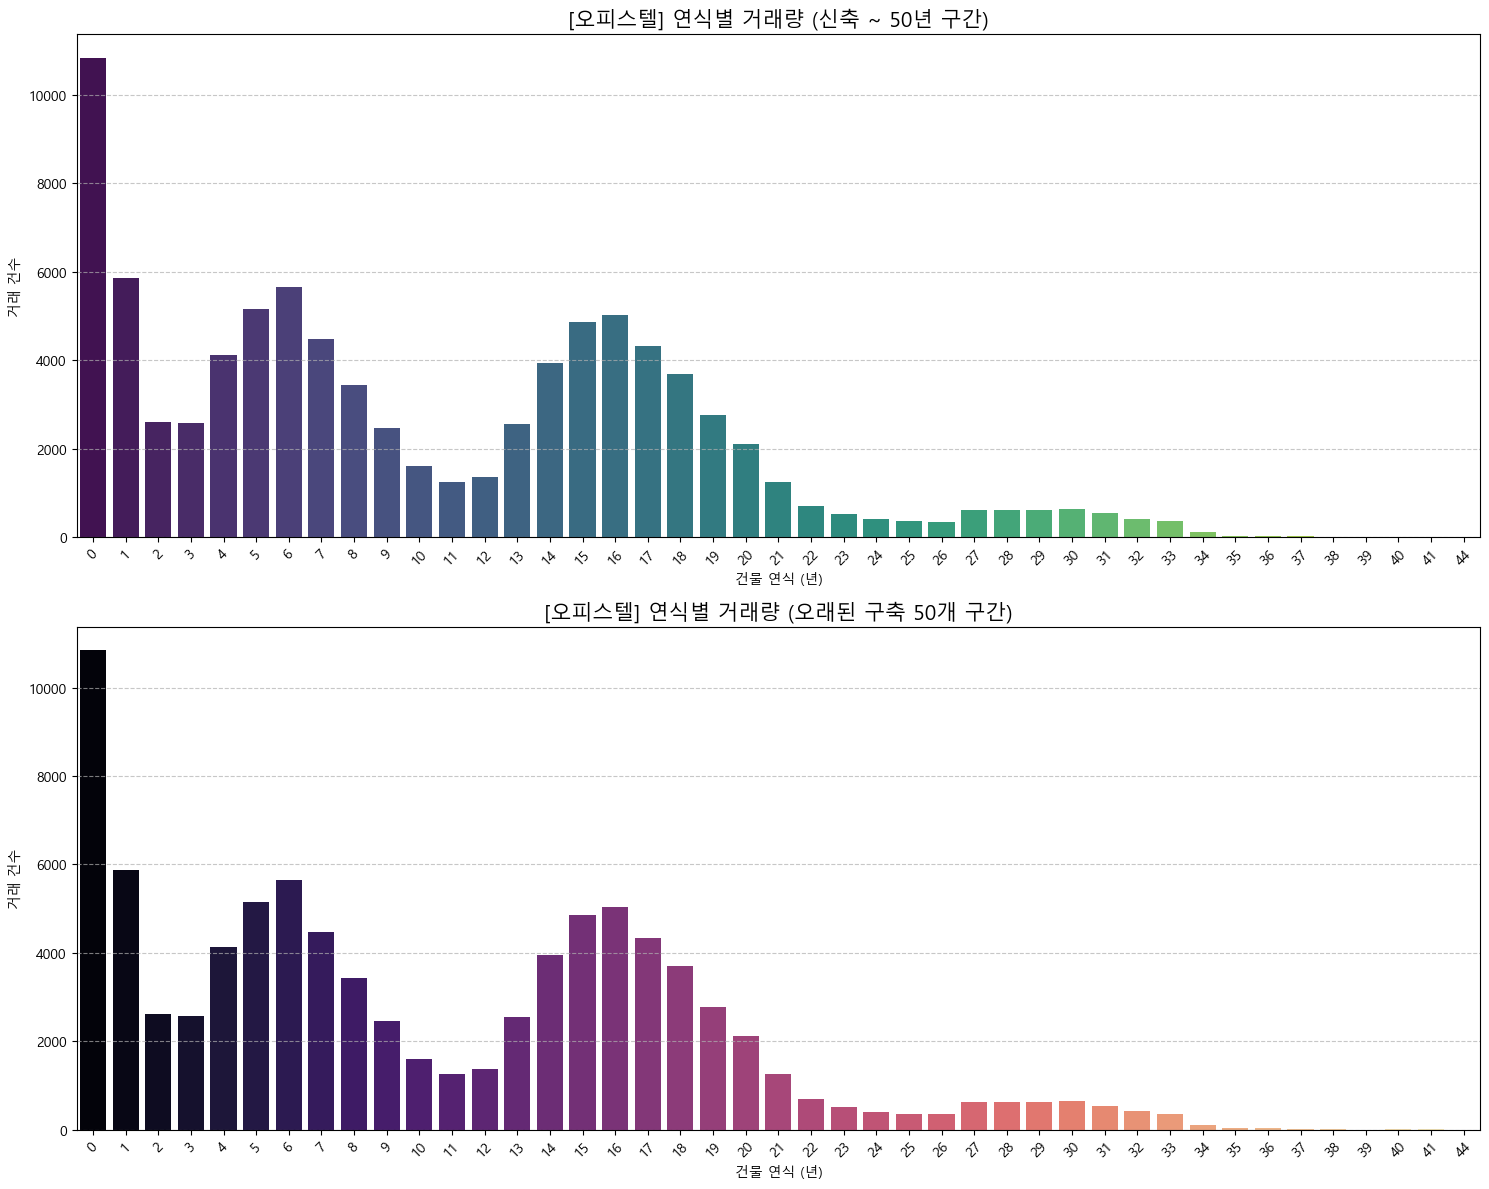

C:\Users\gorhk\AppData\Local\Temp\ipykernel_10016\271226823.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=head_50.index, y=head_50.values, ax=axes[0], palette='viridis')
C:\Users\gorhk\AppData\Local\Temp\ipykernel_10016\271226823.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tail_50.index, y=tail_50.values, ax=axes[1], palette='magma')


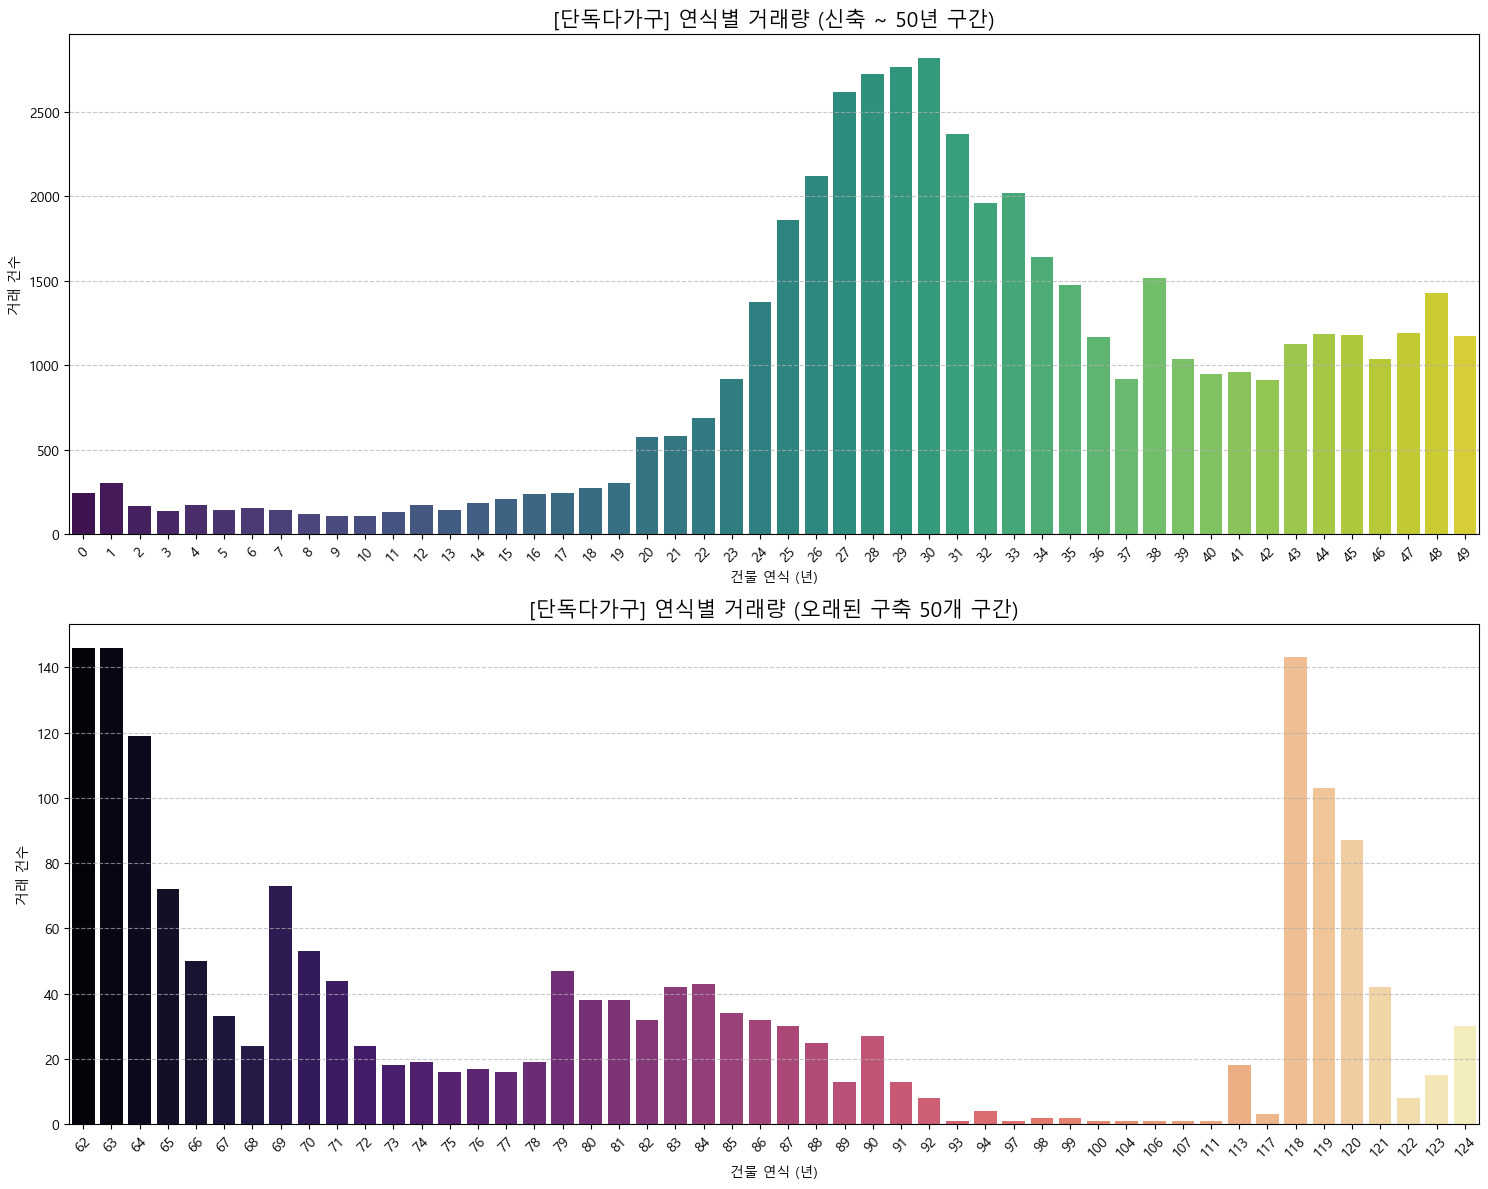

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
system_name = platform.system()
if system_name == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif system_name == 'Darwin':
    plt.rc('font', family='AppleGothic')
else:
    plt.rc('font', family='NanumGothic')
# 1. 0년 이상 150 이하 데이터만 필터링
df_valid_age = df2[(df2['CTRT_BLDG_AGE'] >= 0) & (df2['CTRT_BLDG_AGE'] < 150)]

# 2. 건물 용도 리스트 추출
building_types = df_valid_age['BLDG_USG'].unique()

for b_type in building_types:
    # 해당 용도의 데이터만 추출
    subset = df_valid_age[df_valid_age['BLDG_USG'] == b_type]
    
    # [수정됨] 평균(.mean) 대신 개수(.count) 또는 .value_counts() 사용
    # subset['CTRT_BLDG_AGE'] 컬럼 하나만 잡고 value_counts() 하는 것이 가장 간편합니다.
    age_counts = subset['CTRT_BLDG_AGE'].value_counts().sort_index()
    
    # 데이터가 너무 적으면 예외 처리
    if len(age_counts) < 10:
        continue

    # --- 상위 50개 연식 구간 (신축 ~) ---
    head_50 = age_counts.head(50)
    
    # --- 하위 50개 연식 구간 (구축 ~) ---
    tail_50 = age_counts.tail(50)
    
    # 그래프 그리기
    fig, axes = plt.subplots(2, 1, figsize=(15, 12))
    
    # 1) 상위 50개 그래프 (신축 구간)
    sns.barplot(x=head_50.index, y=head_50.values, ax=axes[0], palette='viridis')
    axes[0].set_title(f'[{b_type}] 연식별 거래량 (신축 ~ 50년 구간)', fontsize=15)
    axes[0].set_xlabel('건물 연식 (년)')
    axes[0].set_ylabel('거래 건수')
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].grid(axis='y', linestyle='--', alpha=0.7)

    # 2) 하위 50개 그래프 (구축 구간)
    sns.barplot(x=tail_50.index, y=tail_50.values, ax=axes[1], palette='magma')
    axes[1].set_title(f'[{b_type}] 연식별 거래량 (오래된 구축 50개 구간)', fontsize=15)
    axes[1].set_xlabel('건물 연식 (년)')
    axes[1].set_ylabel('거래 건수')
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show() 

C:\Users\gorhk\AppData\Local\Temp\ipykernel_10016\4049415635.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top50_volume_ages.index, y=top50_volume_ages.values, palette='viridis')


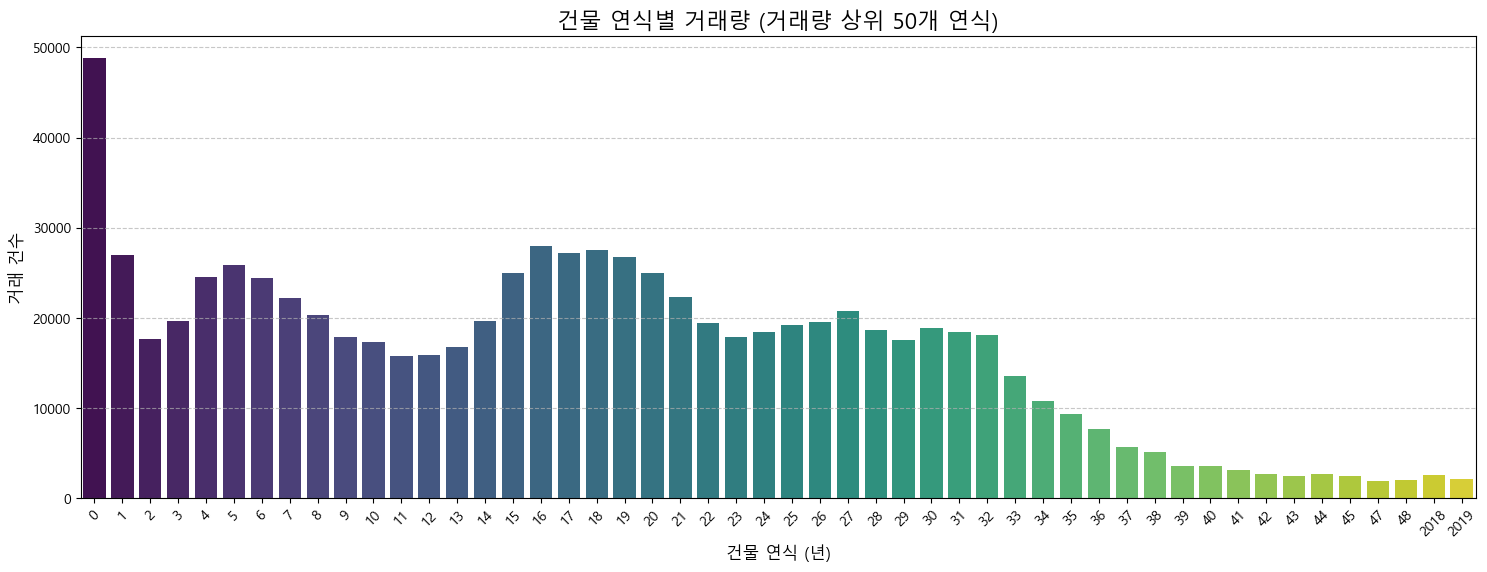

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 거래량이 가장 많은 상위 50개 연식 추출
# (빈도수가 높은 순서대로 50개를 먼저 뽑습니다.)
top50_volume_ages = df2['CTRT_BLDG_AGE'].value_counts().head(50)

# 2. 시각화를 위해 인덱스(연식) 순으로 정렬 (-1년, 0년, 1년...)
top50_volume_ages = top50_volume_ages.sort_index()

# 3. 막대그래프 시각화
plt.figure(figsize=(18, 6))
sns.barplot(x=top50_volume_ages.index, y=top50_volume_ages.values, palette='viridis')

plt.title('건물 연식별 거래량 (거래량 상위 50개 연식)', fontsize=16)
plt.xlabel('건물 연식 (년)', fontsize=12)
plt.ylabel('거래 건수', fontsize=12)
plt.xticks(rotation=45) 
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

C:\Users\gorhk\AppData\Local\Temp\ipykernel_10016\1494169947.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_price_top50.index, y=avg_price_top50.values, palette='Blues_d')


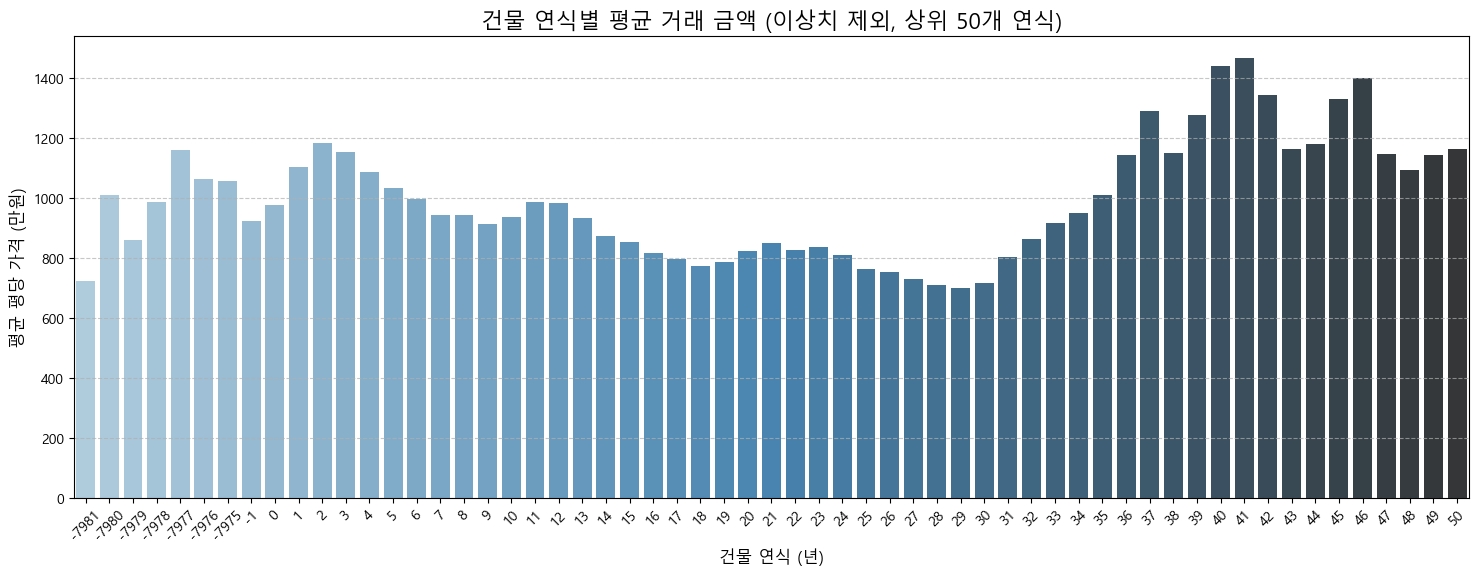

In [17]:
# 평단가 파생컬럼 생성
df2["AMT_PER_AREA"] = df2["THING_AMT"] / df2['ARCH_AREA']

# 1. 이상치(건축년도 0 등) 제거: 연식이 50년 이하인 데이터만 필터링
df_valid = df2[df2['CTRT_BLDG_AGE'] <= 50]

# 2. 해당 연식들의 평균 거래 금액(THING_AMT) 계산
avg_price_top50 = df_valid.groupby('CTRT_BLDG_AGE')['AMT_PER_AREA'].mean()

# 3. 연식 순서대로 정렬 (시간 흐름에 따른 가격 확인용)
avg_price_top50 = avg_price_top50.sort_index()

# 4. 시각화
plt.figure(figsize=(18, 6))
sns.barplot(x=avg_price_top50.index, y=avg_price_top50.values, palette='Blues_d')

plt.title('건물 연식별 평균 거래 금액 (이상치 제외, 상위 50개 연식)', fontsize=16)
plt.xlabel('건물 연식 (년)', fontsize=12)
plt.ylabel('평균 평당 가격 (만원)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

,CGG_CD,CGG_NM,STDG_CD,STDG_NM,BLDG_NM,CTRT_DAY,THING_AMT,ARCH_AREA,LAND_AREA,FLR,RGHT_SE,RTRCN_DAY,ARCH_YR,BLDG_USG,DCLR_SE,CTRT_YEAR,CTRT_YR,CTRT_BLDG_AGE,AMT_PER_AREA
0,11500,강서구,10300,화곡동,"우장산아이파크,이편한세상",2019-04-25,95000,102,NaN,10,NaN,NaN,2008,아파트,NaN,2019,2019,11,935
1,11410,서대문구,11200,대현동,럭키대현,2019-03-16,70000,83,NaN,10,NaN,NaN,1999,아파트,NaN,2019,2019,20,840
2,11590,동작구,10700,사당동,현대,2019-02-21,49500,52,NaN,10,NaN,NaN,1991,아파트,NaN,2019,2019,28,958
3,11350,노원구,10500,상계동,초산빌라,2019-01-21,16000,41,18,1,NaN,NaN,1996,연립다세대,NaN,2019,2019,23,387
4,11380,은평구,11000,증산동,궁전맨션(189-63),2019-01-03,43000,54,27,2,NaN,NaN,1992,연립다세대,NaN,2019,2019,27,791
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
833609,11530,구로구,10700,개봉동,금석연립(170-33),2022-07-08,9190,54,124,1,NaN,20240207,1981,연립다세대,중개거래,2022,2022,41,171
833610,11530,구로구,10700,개봉동,금석연립(170-33),2022-07-08,9190,54,124,1,NaN,20240207,1981,연립다세대,중개거래,2022,2022,41,171
833611,11530,구로구,10700,개봉동,금석연립(170-33),2022-07-08,9740,54,124,2,NaN,20240207,1981,연립다세대,중개거래,2022,2022,41,182
833612,11440,마포구,11000,노고산동,NaN,2021-07-19,195000,157,117,NaN,NaN,20240417,1988,단독다가구,NaN,2021,2021,33,1238


C:\Users\gorhk\AppData\Local\Temp\ipykernel_10016\2518408966.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top50_volume_ages.index, y=top50_volume_ages.values, palette='viridis')


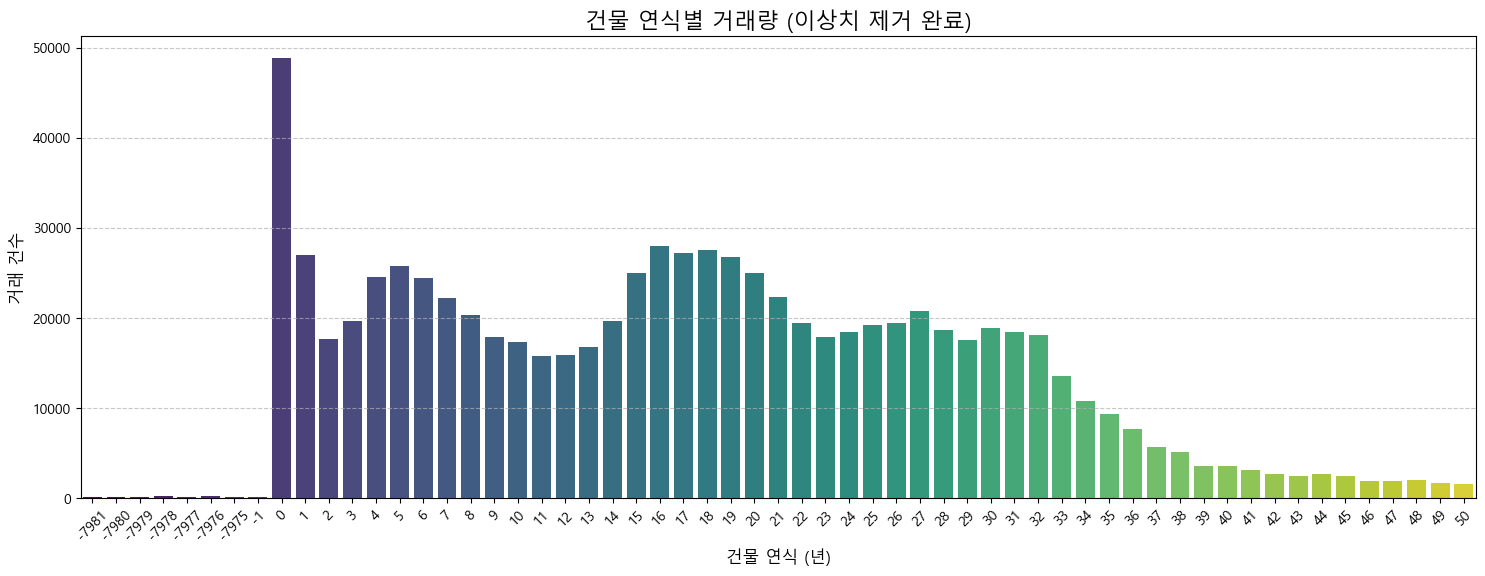

In [18]:
# 1. 이상치 제거: 연식이 50 초과인 데이터(건축년도 0인 건 등)는 제외
# (일반적인 건물을 다루므로 50년 이하면 충분히 안전합니다)
df_qty_valid = df2[df2['CTRT_BLDG_AGE'] <= 50]
display(df_qty_valid)
# 2. 거래량 기준 상위 50개 연식 추출 (정제된 데이터 df_valid 사용)
top50_volume_ages = df_qty_valid['CTRT_BLDG_AGE'].value_counts().sort_index()

# 3. 시각화
plt.figure(figsize=(18, 6))
sns.barplot(x=top50_volume_ages.index, y=top50_volume_ages.values, palette='viridis')

plt.title('건물 연식별 거래량 (이상치 제거 완료)', fontsize=16)
plt.xlabel('건물 연식 (년)', fontsize=12)
plt.ylabel('거래 건수', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [22]:
# # 컬럼명 영문 변환
# cols_rename_map = {
#     '자치구코드': 'CGG_CD', '자치구명': 'CGG_NM', '법정동코드': 'STDG_CD', '법정동명': 'STDG_NM',
#     '건물명': 'BLDG_NM', '계약일': 'CTRT_DAY', '물건금액(만원)': 'THING_AMT',
#     '건물면적(㎡)': 'ARCH_AREA', '토지면적(㎡)': 'LAND_AREA', '층': 'FLR',
#     '권리구분': 'RGHT_SE', '취소일': 'RTRCN_DAY', '건축년도': 'ARCH_YR',
#     '건물용도': 'BLDG_USG', '신고구분': 'DCLR_SE', '지번구분': 'LOTNO_SE'
# }
# df.rename(columns=cols_rename_map, inplace=True)
# 
# # 파생변수 생성: 연식 (CTRT_BLDG_AGE)
# df['CTRT_YEAR'] = df['CTRT_DAY'].astype(str).str[:4].astype(int)
# df = df[pd.to_numeric(df['ARCH_YR'], errors='coerce') > 0]
# df['ARCH_YR'] = df['ARCH_YR'].astype(int)
# df['CTRT_BLDG_AGE'] = df['CTRT_YEAR'] - df['ARCH_YR']
# df = df[df['CTRT_BLDG_AGE'] >= 0]
# 
# # -------------------------------------------------------
# # 2. 심층 분석: 0년차 vs 30년 이상 비교
# # -------------------------------------------------------
# # 0년차와 30년 이상 데이터만 추출
# age_0 = df[df['CTRT_BLDG_AGE'] == 0]
# age_30 = df[df['CTRT_BLDG_AGE'] >= 30]
# 
# print(f"=== [연식 0년차] 거래 건수: {len(age_0)}건 ===")
# print(age_0['BLDG_USG'].value_counts(normalize=True)) # 비율 확인
# 
# print(f"\n=== [연식 30년 이상] 거래 건수: {len(age_30)}건 ===")
# print(age_30['BLDG_USG'].value_counts(normalize=True))
# 
# # -------------------------------------------------------
# # 3. 시각화: 연식별 건물 용도 구성 비율 (Stacked Bar)
# # -------------------------------------------------------
# # 연식을 그룹화 (0년, 1~9년, 10~29년, 30년 이상)
# def get_age_group(x):
#     if x == 0: return '0년(신축)'
#     elif x < 10: return '1~9년(준신축)'
#     elif x < 30: return '10~29년(구축)'
#     else: return '30년+(재건축)'
# 
# 
# # 그룹별, 용도별 개수 계산
# cross_tab = pd.crosstab(df['Age_Group'], df['BLDG_USG'], normalize='index')
# 
# # 순서 정렬
# order = ['0년(신축)', '1~9년(준신축)', '10~29년(구축)', '30년+(재건축)']
# cross_tab = cross_tab.reindex(order)
# 
# # 시각화
# plt.figure(figsize=(12, 6))
# plt.rc('font', family='Malgun Gothic') 
# 
# cross_tab.plot(kind='bar', stacked=True, colormap='Set2', figsize=(10, 6))
# plt.title('연식 구간별 건물 용도 구성 비율 (이게 바로 원인입니다!)', fontsize=15)
# plt.ylabel('비율 (1.0 = 100%)')
# plt.xlabel('연식 구간')
# plt.legend(title='건물 용도', bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.xticks(rotation=0)
# plt.tight_layout()
# plt.show()
# 
# # -------------------------------------------------------
# # 4. 진짜 가격 비교: 용도를 '아파트'로만 한정했을 때
# # -------------------------------------------------------
# apt_df = df[df['BLDG_USG'] == '아파트']
# apt_age_price = apt_df.groupby('CTRT_BLDG_AGE')['THING_AMT'].mean()
# 
# print("\n=== [아파트만 필터링했을 때] 연식별 평균 가격 ===")
# print(f"0년차 아파트 평균가: {apt_age_price.get(0, 0):.0f} 만원")
# print(f"30년차 아파트 평균가: {apt_age_price.get(30, 0):.0f} 만원")

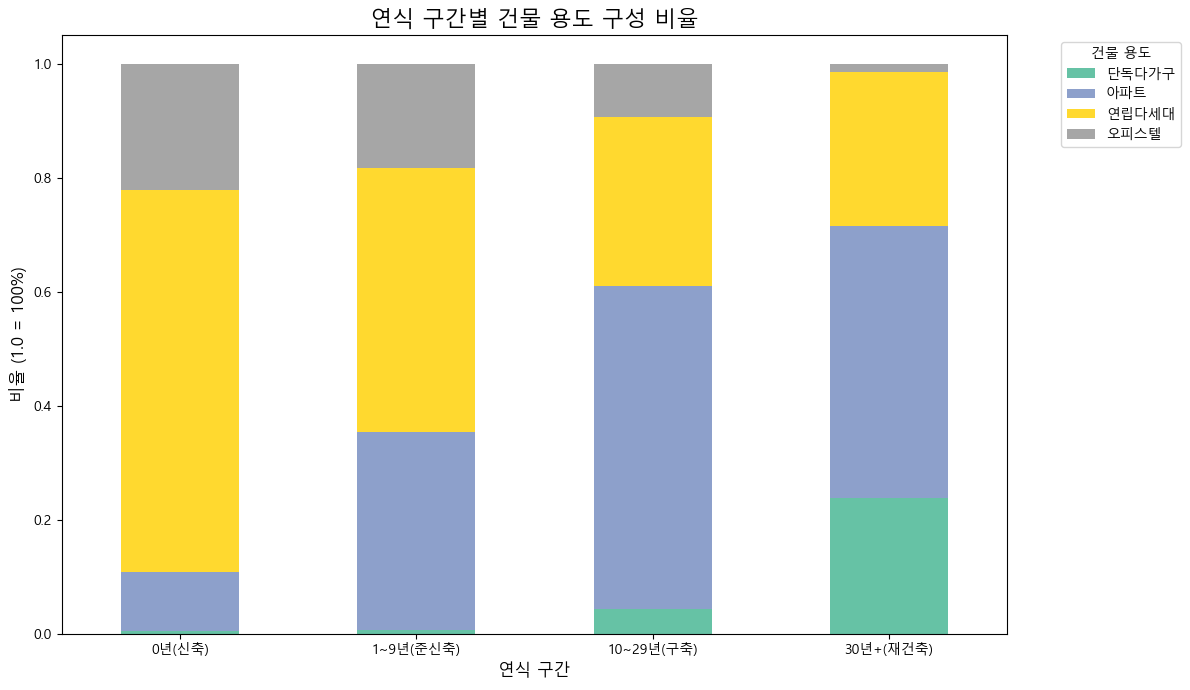

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import platform

# --- 한글 폰트 설정 ---
system_name = platform.system()
if system_name == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif system_name == 'Darwin':
    plt.rc('font', family='AppleGothic')
else:
    plt.rc('font', family='NanumGothic')
plt.rc('axes', unicode_minus=False)
# ---------------------

# 1. 데이터 복사 및 전처리 (음수 연식 제거)
df_valid = df2[df2['CTRT_BLDG_AGE'] >= 0].copy()

# 2. 연식 구간(Category) 정의 함수
def categorise_age(age):
    if age == 0:
        return '0년(신축)'
    elif 1 <= age <= 9:
        return '1~9년(준신축)'
    elif 10 <= age <= 29:
        return '10~29년(구축)'
    else: # 30년 이상
        return '30년+(재건축)'

# 3. 'Age_Group' 컬럼 생성
df_valid['Age_Group'] = df_valid['CTRT_BLDG_AGE'].apply(categorise_age)

# 4. 교차표(Crosstab) 생성: 인덱스=연식구간, 컬럼=건물용도
# normalize='index'를 사용하여 행별 합계가 1(100%)이 되도록 비율로 변환
age_type_ratio = pd.crosstab(df_valid['Age_Group'], df_valid['BLDG_USG'], normalize='index')

# 5. 인덱스(x축) 순서 지정 (논리적 순서대로 정렬)
desired_order = ['0년(신축)', '1~9년(준신축)', '10~29년(구축)', '30년+(재건축)']
age_type_ratio = age_type_ratio.reindex(desired_order)

# 6. 컬럼(범례) 순서 지정 (이미지와 유사하게)
# 데이터에 존재하는 용도만 선택하여 순서 지정
available_cols = age_type_ratio.columns.tolist()
# 원하는 순서 예시: 단독다가구 -> 아파트 -> 연립다세대 -> 오피스텔 (데이터에 있는 것만 남김)
target_cols_order = ['단독다가구', '아파트', '연립다세대', '오피스텔']
sorted_cols = [c for c in target_cols_order if c in available_cols]
# 만약 위 리스트에 없는 다른 용도가 있다면 뒤에 추가
remaining_cols = [c for c in available_cols if c not in sorted_cols]
final_cols = sorted_cols + remaining_cols

age_type_ratio = age_type_ratio[final_cols]

# 7. 색상 매핑 (이미지와 유사한 컬러 코드로 지정)
color_map = {
    '단독다가구': '#66c2a5', # 녹색 계열
    '아파트': '#8da0cb',     # 파란색 계열
    '연립다세대': '#ffd92f', # 노란색 계열
    '오피스텔': '#a6a6a6',   # 회색 계열
}
# 데이터에 있는 컬럼만 색상 리스트 생성
colors = [color_map.get(col, '#d3d3d3') for col in age_type_ratio.columns]

# 8. 그래프 그리기
ax = age_type_ratio.plot(
    kind='bar', 
    stacked=True, 
    figsize=(12, 7), 
    color=colors,
    width=0.5 # 막대 너비 조절
)

plt.title('연식 구간별 건물 용도 구성 비율', fontsize=16)
plt.xlabel('연식 구간', fontsize=12)
plt.ylabel('비율 (1.0 = 100%)', fontsize=12)
plt.xticks(rotation=0) # x축 라벨 가로로 표시

# 범례 위치 조정 (그래프 밖 우측 상단)
plt.legend(title='건물 용도', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [27]:
import pandas as pd

# 0년 이하 등 이상치 제거 (필요시 사용, 여기선 0보다 큰 값만 사용)
target_df = df2[df2['ARCH_YR'] > 0].copy()

# 행: 건축년도(ARCH_YR), 열: 건물용도(BLDG_USG) 로 개수(count) 집계
table_counts = pd.crosstab(index=target_df['ARCH_YR'], columns=target_df['BLDG_USG'])

# 건축년도 순으로 정렬 (인덱스 정렬)
table_counts = table_counts.sort_index()

# 상위 5개 행 미리보기
table_counts

# 전체 표를 엑셀로 저장하고 싶다면:
# table_counts.to_csv("building_year_counts.csv", encoding='euc-kr')

BLDG_USG,단독다가구,아파트,연립다세대,오피스텔
ARCH_YR,,,,
970,1,0,0,0
1900,422,0,0,0
1901,9,0,0,0
1909,1,0,0,0
1911,18,0,0,0
1912,2,0,0,0
1920,2,0,0,0
1921,2,0,0,0
1922,1,0,0,0
